2025-01-23 13:03:00,330 - Total processing time: 0.61 seconds


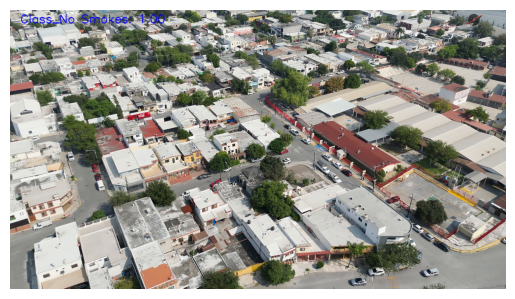

AttributeError: 'VideoProcessor' object has no attribute 'fire_class_labels'

In [3]:
import torch
import cv2
import time
import logging
from pydantic import BaseModel, field_validator
from typing import Any
from PIL import Image
import torch
from torchvision import models, transforms
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import cv2
import numpy as np
from pydantic import BaseModel, field_validator
from ultralytics import YOLO
import supervision as sv

from torchvision import models
import torch.nn as nn
import torch
import os
from PIL import Image
import torchvision.transforms as transforms

from pathlib import Path
# Assuming these paths and constants are set correctly
MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"  # Path to the ResNet model
LOGO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\logo.png"  # Path to the logo
ICON_PERSONA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\smoke.png"  # Path to persona icon

# Model Paths
EYE_V_DET_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Segmentation\Object Segmentation.v3i.yolov8\runs\segment\train6\weights\best.pt"
EYE_T_DET_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Segmentation\Object Segmentation.v3i.yolov8\runs\segment\train6\weights\best.pt"
SMOKE_V_CLASS_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"
SMOKE_T_CLASS_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"
FIRE_V_CLASS_MODEL_PATH = r"C:\Users\Spacelab4\Documents\SkyProtector-IA\fire-detection\training\weights\best.pt"
FIRE_T_CLASS_MODEL_PATH = r"C:\Users\Spacelab4\Documents\SkyProtector-IA\fire-detection\training\weights\best.pt"

# Overlay Paths
LOGO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\logo.png"
ICON_PERSONA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\persona.png"
ICON_CARRO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\carro.png"
ICON_CAMIONETA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\camioneta.png"
ICON_CAMION_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\camion.png"
ICON_MOTO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\moto.png"


class ModelManager:
    """
    Loads the appropriate model for image classification based on the task type
    and allocates the device (GPU or CPU).
    """
    def __init__(self):

        # Define image transformation pipeline for preprocessing
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.load_smoke_model(MODEL_PATH)
        self.models = {
            #"eye_v": YOLO(self.eye_v_model).to(self.device),
            #"eye_t": YOLO(self.eye_t_model).to(self.device),
            "smoke_v": self.smoke_classification_model.to(self.device),
            "smoke_t": self.smoke_classification_model.to(self.device),
            #"fire_v": self.fire_classification_model.to(self.device),
            #"fire_t": self.fire_classification_model.to(self.device),
        } 
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    
    def get_model(self, task_type: str):
        """
        Returns the model based on the task type.

        :param task_type: The task type for which the model is required.

        :return: Model for the specified task type or None if the task type is invalid.

        """

        return self.models.get(task_type)
    
    def load_fire_model(self):
        model = models.efficientnet_b4(weights=None)
        model.classifier = nn.Linear(model.classifier[1].in_features, 2)

        checkpoint = torch.load(FIRE_V_CLASS_MODEL_PATH, weights_only=True)
        model.load_state_dict(checkpoint['model_state_dict'])
        self.fire_classification_model = model

    def load_smoke_model(self, model_path):
        """
        Returns the ResNet model for classification.
        """
        self.smoke_classification_model = models.resnet18(pretrained=True)
        self.smoke_classification_model.fc = nn.Linear(self.smoke_classification_model.fc.in_features, 1000)  # Adjust to match the original model's output units
        self.smoke_classification_model.load_state_dict(torch.load(model_path , map_location=self.device)) # , map_location=self.device # strict = False
        self.smoke_classification_model.eval()

        return self.smoke_classification_model


    def predict(self, frame: np.ndarray):
        """
        Predict the class of the image using the ResNet model.

        :param frame: The input image for classification.
        :return: Predicted class label and probability.
        """
        input_tensor = self.transform(frame).unsqueeze(0).to(self.device)
        with torch.no_grad():
            output = self.smoke_classification_model(input_tensor)
        
        probabilities = torch.nn.functional.softmax(output, dim=1)
        predicted_class = torch.argmax(probabilities, dim=1).item()
        predicted_prob = probabilities[0, predicted_class].item()
        
        return predicted_class, predicted_prob

class OverlayUtils:
    """
    Handles the addition of logos, icons, and class labels to frames.
    """
    def __init__(self):
        
        self.model_manager = ModelManager()
        #print(self.model_manager.get_model(task_type="smoke_v"))
        self.class_names = ["NoSmokes", "Smokes"]#self.model_manager.get_model(task_type="smoke_v").names

        self.logo = cv2.imread(LOGO_PATH, cv2.IMREAD_UNCHANGED)
        self.icons = {
            "persona": cv2.imread(ICON_PERSONA_PATH, cv2.IMREAD_UNCHANGED),
            "carro": cv2.flip(cv2.imread(ICON_CARRO_PATH, cv2.IMREAD_UNCHANGED), 1),
            "camioneta": cv2.imread(ICON_CAMIONETA_PATH, cv2.IMREAD_UNCHANGED),
            "camion": cv2.imread(ICON_CAMION_PATH, cv2.IMREAD_UNCHANGED),
            "moto": cv2.imread(ICON_MOTO_PATH, cv2.IMREAD_UNCHANGED),
        }

        self.logo = cv2.imread(LOGO_PATH, cv2.IMREAD_UNCHANGED)
        self.icons = {
            "persona": cv2.imread(ICON_PERSONA_PATH, cv2.IMREAD_UNCHANGED),

        }
        self.class_palette = sv.ColorPalette([
            sv.Color(0, 255, 127),   # Person: Bright Spring Green
            sv.Color(255, 165, 0),   # Small Vehicle: Orange
            sv.Color(255, 69, 0),    # Medium Vehicle: Red-Orange
            sv.Color(255, 0, 0),     # Large Vehicle: Red
            sv.Color(138, 43, 226)   # Motorcycle: Blue-Violet
        ])
        
    def add_logo(self, frame: np.ndarray, position='top-right', logo_transparency=0.4) -> np.ndarray:
        """
        Resize and add the logo to the frame with transparency.

        :param frame: The frame to which the overlay will be added.
        :param position: Position to place the logo ('top-left', 'top-right', etc.).
        :param logo_transparency: Transparency level of the logo.
        :return: Frame with the logo overlay.
        """
        frame_height, frame_width = frame.shape[0], frame.shape[1]
        scale = 0.08
        scale_factor = min(frame_width, frame_height) * scale
        logo_size = (int(scale_factor), int(scale_factor))
        logo_resized = cv2.resize(self.logo, logo_size)

        logo_height, logo_width = logo_resized.shape[0], logo_resized.shape[1]
        positions = {
            'top-left': (0, 0),
            'top-right': (frame_width - logo_width - 160, 0),
            'bottom-left': (10, frame_height - logo_height),
            'bottom-right': (frame_width - logo_width, frame_height - logo_height),
        }
        top_left_x, top_left_y = positions.get(position, (0, 0))

        logo_rgb = logo_resized[:, :, :3]
        logo_alpha = logo_resized[:, :, 3] / 255.0 * (1 - logo_transparency)
        
        roi = frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width].copy()
        blended = (logo_rgb * logo_alpha[..., None] + roi * (1 - logo_alpha[..., None])).astype(np.uint8)
        frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width] = blended

        return frame

    def add_class_label(self, frame: np.ndarray, class_name: str, prob: float) -> np.ndarray:
        """
        Adds the predicted class label and probability to the frame.

        :param frame: The frame to which the overlay will be added.
        :param class_name: The name of the predicted class.
        :param prob: The probability of the prediction.
        :return: Frame with the class label overlay.
        """
        label = f"{class_name}: {prob:.2f}"
        cv2.putText(frame, label, (80, 100), cv2.FONT_HERSHEY_SIMPLEX, 3, (255, 0, 0), 5)
        return frame
    
    def add_counter(self, frame: np.ndarray, class_counts: dict, bg_transparency=0.6, bg_color=(0, 0, 0)) -> np.ndarray:
        """
        It adjusts the size of the icons and text based on frame size, adds class counters and 
        a background with transparency.

        :param frame: The frame to which the overlay will be added.
        :param class_counts: A dictionary with class names as keys and count values as the values.
        :param bg_transparency:  Transparency of the logo, 0 (fully transparent) to 1.
        :param bg_color: RGB values representing the background color.

        :return: The frame with the counter overlays.

        """
    
        frame_height, frame_width = frame.shape[0], frame.shape[1] 

        reference_width, reference_height = 3840, 2160
        scale_factor = min(frame_width / reference_width, frame_height / reference_height)
        icon_scale = scale_factor + 0.1 

        icon_spacing = int(80 * icon_scale) # 80
        text_scale = 1.2 * icon_scale # 1.2
        text_thickness = int(2.5 * icon_scale) # 3

        icon_width, icon_height = int(50 * icon_scale), int(50 * icon_scale) # 50 
        icon_size = icon_width, icon_height

        padding_x, padding_y = int(30 * icon_scale), int(25 * icon_scale) # 30, 25

        total_icons = len(self.class_names)
        text_width_estimate = int(30 * icon_scale) # 30 
        total_width = (padding_x * 2 + 
                      (icon_width + text_width_estimate) * total_icons + 
                      icon_spacing * (total_icons - 1)) 

        bg_height = icon_height + (padding_y * 2)
        bg_width = total_width + 5
       
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (bg_width, bg_height), bg_color, -1)
        frame = cv2.addWeighted(overlay, bg_transparency, frame, 1 - bg_transparency, 0, frame)

        for i, (class_id, class_name) in enumerate(self.class_names.items()):
            icon = self.icons.get(class_name)
            count = class_counts.get(class_name, 0)

            if icon is not None:
                if icon.shape[2] == 4:
                    icon_rgb = icon[:, :, :3]
                    icon_alpha = icon[:, :, 3] / 255.0
                else:
                    icon_rgb = icon
                    icon_alpha = np.ones(icon_rgb.shape[:2], dtype=float)

                icon_resized = cv2.resize(icon_rgb, icon_size)
                icon_alpha_resized = cv2.resize(icon_alpha, icon_size)

                icon_x_position = padding_x + i * (icon_width + text_width_estimate + icon_spacing)
                icon_y_position = padding_y

                if (icon_x_position + icon_width > frame.shape[1] or 
                    icon_y_position + icon_height > frame.shape[0]):
                    continue
                
                roi = frame[
                    icon_y_position:icon_y_position + icon_height,
                    icon_x_position:icon_x_position + icon_width
                ].copy()

                icon_alpha_3channel = np.stack([icon_alpha_resized] * 3, axis=-1)

                blended = np.uint8(icon_resized * icon_alpha_3channel + 
                                 roi * (1 - icon_alpha_3channel))

                frame[
                    icon_y_position:icon_y_position + icon_height,
                    icon_x_position:icon_x_position + icon_width 
                ] = blended

                count_text = f"{count}"

                text_x_position = icon_x_position + icon_width + int(10 * icon_scale) # 10
                text_y_position = icon_y_position + int(icon_height * 0.75)

                cv2.putText(frame, count_text,
                    (text_x_position, text_y_position),
                    cv2.FONT_HERSHEY_SIMPLEX, text_scale,
                    (0, 0, 0),  text_thickness + int(2 * icon_scale)
                )

                cv2.putText(frame, count_text,
                    (text_x_position, text_y_position),
                    cv2.FONT_HERSHEY_SIMPLEX, text_scale,
                    (255, 255, 255),  text_thickness
                )

        return frame

class Validator(BaseModel):
    """
    Ensures that the frame is correctly formatted and valid.
    """
    frame: Any

    @field_validator("frame")
    def frame_validation(cls, value):
        if not isinstance(value, np.ndarray) or value.size == 0:
            raise ValueError("Frame must be a non-empty ndarray")
        return value

class ImageClassificationProcessor:
    """
    Processes an image using a ResNet model, applies classification, and overlays results.
    """
    def __init__(self):
        self.model_manager = ModelManager()
        self.smoke_v_model = self.model_manager.get_model(task_type="smoke_v")
        self.eye_v_model = self.model_manager.get_model(task_type="eye_v")
        self.eye_t_model = self.model_manager.get_model(task_type="eye_t")
        self.fire_v_model = self.model_manager.get_model(task_type="fire_v")
        self.fire_t_model = self.model_manager.get_model(task_type="fire_t")
        self.smoke_v_model.eval()
        self.overlay_utils = OverlayUtils()
        self.palette = self.overlay_utils.class_palette
        self.class_names = self.overlay_utils.class_names
        self.fire_data_transforms =  transforms.Compose([
            transforms.Resize((224,224)), # resize
            transforms.RandomAdjustSharpness(5.0), #sharpen image
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        self.smoke_data_transforms =  transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.class_labels_fire = {0: 'Fire', 1: 'No Fire'}
        self.class_array_smoke = ["No Smokes","Smokes"]

    def process_frame(self, frame: np.ndarray) -> np.ndarray:
        """
        Processes a frame, performs image classification, and adds overlays.

        :param frame: The frame to be processed.
        :return: Frame with classification results and overlays.
        """
        #  Convert the NumPy array frame from cv2 to a PIL Image
        image = Image.fromarray(frame)

        predicted_class, predicted_prob = self.model_manager.predict(image)
        
        # Convert predicted class to a human-readable label
        
        class_name = "Class_" + self.class_array_smoke[int(predicted_class)]  # You can map it to a real label if you have the labels.
        
        # Add overlays (logo and class label)
        frame_with_logo = self.overlay_utils.add_logo(frame)
        annotated_frame = self.overlay_utils.add_class_label(frame_with_logo, class_name, predicted_prob)

        return annotated_frame
class VideoProcessor:
    """
    Loads a video, applies model, annotates the image,
    and displays results with overlay.

    """

    def __init__(self):

        self.model_manager = ModelManager()
    
        self.smoke_v_model = self.model_manager.load_smoke_model(model_path=MODEL_PATH)
        self.smoke_v_model.eval()

        self.overlay_utils = OverlayUtils()
        self.palette = self.overlay_utils.class_palette
        #self.class_names = self.overlay_utils.class_names

        # Clase 0: fire
        # Clase 1: no fire
        self.smoke_class_labels = {0: 'NoSmokes', 1: 'Smokes'}
        self.count = 0


    def preprocess_frame(self, frame):
        frame = Image.fromarray(frame)
        transform = transforms.Compose([
        transforms.Resize((380, 380)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
        return transform(frame).unsqueeze(0)

    def process_video(self, video_path: str, output_folder: str):
        """
        Loads the video, processes each frame with model object detection, 
        adds overlays, and saves the processed video.

        :param video_path: The path to the input video to be processed.
        :param output_path: The path where the output video will be saved.

        :return: The annotated image or None in case of an error.

        """

        video_path = Path(video_path)
        output_folder = Path(output_folder)

        input_video_name = video_path.stem
        input_extension = video_path.suffix
        output_video_path = output_folder / f"{input_video_name}{input_extension}"

        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            logging.error(f"Failed to open video: {video_path}")

            return None

        fps = cap.get(cv2.CAP_PROP_FPS)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        out = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))

        reference_width, reference_height = 3840, 2160
        scale_factor = round(min(width / reference_width, height / reference_height),1)
       
        box_annotator = sv.BoxCornerAnnotator(
            color=self.palette,
            thickness=int(7 * scale_factor),
            corner_length=int(30 * scale_factor),
            color_lookup=sv.ColorLookup.CLASS
        )
      

        try:
            while cap.isOpened():
                ret, frame = cap.read()

                if not ret:
                    break  

                try:
                    # results = self.eye_v_model(frame, conf=0.40, verbose=False)

                    # detections = sv.Detections.from_ultralytics(results[0])
                    # annotated_frame = box_annotator.annotate(scene=frame, detections=detections)

                    # class_counts = {class_name: 0 for class_name in self.class_names.values()}
                    # for i, class_name in enumerate(self.class_names.values()):
                    #     class_detections = detections[detections.class_id == i]
                    #     class_counts[class_name] = len(class_detections)

                    # validator = Validator(frame=annotated_frame, counts=class_counts)
                    # val_frame_logo = self.overlay_utils.add_logo(validator.frame)

                    # out.write(val_frame_logo)

                    # Fire Classification
                    input_tensor = self.preprocess_frame(frame)#.to(self.model_manager.device)

                    with torch.no_grad():
                        outputs = self.smoke_v_model(input_tensor)

                    # Obtener la clase predicha
                    _, predicted_class = torch.max(outputs, 1)
                    fire_text = self.smoke_class_labels[predicted_class.item()]
                    print(f"Prediccion: {self.fire_class_labels[predicted_class.item()]}")
                    self.count += 1

                    if(predicted_class == 1):
                        prediction = False
                    elif(predicted_class == 0):
                        prediction = True

                    # Agrega texto de predicción de fuego
                    text_scale = 5 * scale_factor
                    text_thickness = int(10 * scale_factor)
                    text_color = (0, 0, 255) if prediction else (0, 255, 0)
                    text_position = (120, 120)  # Posición del texto

                    cv2.putText(
                        frame,
                        fire_text,
                        text_position,
                        cv2.FONT_HERSHEY_SIMPLEX,
                        text_scale,
                        text_color,
                        text_thickness
                    )

                    val_frame_logo = self.overlay_utils.add_logo(frame)

                    # Escribe el frame procesado en el video de salida
                    out.write(val_frame_logo)


                except RuntimeError as e:
                    logging.error(f"Error during video processing: {e}")

                    continue

        finally:
            cap.release()
            out.release()

        return prediction, val_frame_logo
if __name__ == "__main__":
    # Test the image classification processor
    ia_frame_processor = ImageClassificationProcessor()
    IMAGE_PATH = "C:/Users/Spacelab3/Desktop/envs/Classifier/VideoTest2/VideoTestVideo_Frame_67.jpg"
    frame = cv2.imread(IMAGE_PATH)
        
    start_time = time.time()
    ann_frame = ia_frame_processor.process_frame(frame)
    end_time = time.time()

    processing_time = end_time - start_time
    logging.info(f"Total processing time: {processing_time:.2f} seconds")
    
    resize_ann_frame = cv2.resize(ann_frame, (1280, 720))
    plt.imshow(cv2.cvtColor(resize_ann_frame, cv2.COLOR_BGR2RGB))
    plt.axis('off')  # Hides the axes and ticks
    plt.show()
    
    video_processor = VideoProcessor()
    video_path = Path(r"C:\Users\Spacelab3\Desktop\envs\Classifier\Videos\DroneVideoNightCity - Copy.mp4")
    output_folder = Path(r"C:\Users\Spacelab3\Desktop\envs\Classifier\Videos\Test")
    start_time = time.time()  
    prediction_fire, video = video_processor.process_video(video_path, output_folder)
    end_time = time.time()
    processing_time = end_time - start_time
    logging.info(f"Total processing time: {processing_time:.2f} seconds")

In [11]:
import logging
import time
from collections import defaultdict
from pathlib import Path
from typing import Any, Dict, List, Optional
import math

import cv2
import numpy as np
import torch
from pydantic import BaseModel, field_validator
from ultralytics import YOLO
import supervision as sv


logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(message)s"
)


# Model Paths
EYE_V_DET_MODEL_PATH = r"C:\Users\Cesar Spacelab\Documents\Roberto Spacelab\git\HuggingFace\SkyProtector-IA\SkyProtector\YOLO11\DET\s\eye_V_1.pt"
EYE_T_DET_MODEL_PATH = r"C:\Users\Cesar Spacelab\Documents\Roberto Spacelab\git\HuggingFace\SkyProtector-IA\SkyProtector\YOLO11\DET\s\eye_V_1.pt"

EYE_V_SEG_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Segmentation\Object Segmentation.v3i.yolov8\runs\segment\train6\weights\best.pt"


# Assuming these paths and constants are set correctly
MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"  # Path to the ResNet model
LOGO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\logo.png"  # Path to the logo
ICON_PERSONA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\smoke.png"  # Path to persona icon

# Model Paths
EYE_V_DET_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Segmentation\Object Segmentation.v3i.yolov8\runs\segment\train6\weights\best.pt"
EYE_T_DET_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Segmentation\Object Segmentation.v3i.yolov8\runs\segment\train6\weights\best.pt"
SMOKE_V_CLASS_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"
SMOKE_T_CLASS_MODEL_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\smoke_classification_model_40_night.pth"
FIRE_V_CLASS_MODEL_PATH = r"C:\Users\Spacelab4\Documents\SkyProtector-IA\fire-detection\training\weights\best.pt"
FIRE_T_CLASS_MODEL_PATH = r"C:\Users\Spacelab4\Documents\SkyProtector-IA\fire-detection\training\weights\best.pt"

# Overlay Paths
LOGO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\logo.png"
ICON_PERSONA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\persona.png"
ICON_CARRO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\carro.png"
ICON_CAMIONETA_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\camioneta.png"
ICON_CAMION_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\camion.png"
ICON_MOTO_PATH = r"C:\Users\Spacelab3\Desktop\envs\Classifier\assets\icons\moto.png"

class ModelManager:
    """
    It loads the appropriate model for image or video processing
    based on the task type and allocates the device (GPU or CPU).

    """

    def __init__(self):

        self.eye_v_model = EYE_V_DET_MODEL_PATH
        self.eye_t_model = EYE_T_DET_MODEL_PATH
        self.eye_vs_model = EYE_V_SEG_MODEL_PATH
        self.smoke_v_model = SMOKE_V_CLASS_MODEL_PATH
        self.smoke_t_model = SMOKE_T_CLASS_MODEL_PATH
        self.fire_v_model = FIRE_V_CLASS_MODEL_PATH
        self.fire_t_model = FIRE_T_CLASS_MODEL_PATH

        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.models = {
            "eye_v": YOLO(self.eye_v_model).to(self.device),
            "eye_t": YOLO(self.eye_t_model).to(self.device),
            "eye_vs": YOLO(self.eye_vs_model).to(self.device),
   
        }

    def get_model(self, task_type: str):
        """
        Returns the model based on the task type.

        :param task_type: The task type for which the model is required.

        :return: Model for the specified task type or None if the task type is invalid.

        """

        return self.models.get(task_type)


class OverlayUtils:
    """
    It handles the addition of logos, icons, and class counters to frames 
    based on the frame size.

    """

    def __init__(self):

        self.model_manager = ModelManager()
        self.class_names = self.model_manager.get_model(task_type="eye_vs").names

        self.logo = cv2.imread(LOGO_PATH, cv2.IMREAD_UNCHANGED)
        self.icons = {
            "Person": cv2.imread(ICON_PERSONA_PATH, cv2.IMREAD_UNCHANGED),
            "Car": cv2.flip(cv2.imread(ICON_CARRO_PATH, cv2.IMREAD_UNCHANGED), 1),
            "Van": cv2.imread(ICON_CAMIONETA_PATH, cv2.IMREAD_UNCHANGED),
            "Truck": cv2.imread(ICON_CAMION_PATH, cv2.IMREAD_UNCHANGED),
            "Motorcycle": cv2.imread(ICON_MOTO_PATH, cv2.IMREAD_UNCHANGED),
        }

        self.class_palette = sv.ColorPalette([
            sv.Color(0, 255, 127),   # Person: Bright Spring Green
            sv.Color(255, 165, 0),   # Small Vehicle: Orange
            sv.Color(255, 69, 0),    # Medium Vehicle: Red-Orange
            sv.Color(255, 0, 0),     # Large Vehicle: Red
            sv.Color(138, 43, 226)   # Motorcycle: Blue-Violet
        ])
        
    def add_logo(self, frame: np.ndarray, position='top-right', logo_transparency=0.4) -> np.ndarray:
        """
        It resizes the logo based on the frame's size and places it at the 
        specified position on the frame with transparency.

        :param frame: The frame to which the overlay will be added.
        :param position: Logo position on frame ('top-left', 'top-right', 'bottom-left', 'bottom-right').
        :param logo_transparency: Transparency of the logo, 0 (fully transparent) to 1.

        :return: The frame with the logo overlay.

        """

        frame_height, frame_width = frame.shape[0], frame.shape[1]

        scale = 0.08
        scale_factor = min(frame_width, frame_height) * scale 
        logo_size = (int(scale_factor), int(scale_factor))
        logo_resized = cv2.resize(self.logo, logo_size)

        logo_width, logo_height = logo_resized.shape[1], logo_resized.shape[0]
        positions = {
            'top-left': (0, 0),
            'top-right': (frame_width - logo_width - 0, 0),
            'bottom-left': (10, frame_height - logo_height),
            'bottom-right': (frame_width - logo_width, frame_height - logo_height),
        }

        top_left_x, top_left_y = positions.get(position, (0, 0))

        logo_rgb = logo_resized[:, :, :3]
        logo_alpha = logo_resized[:, :, 3] / 255.0 * (1 - logo_transparency)
        roi = frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width].copy()
        blended = (logo_rgb * logo_alpha[..., None] + roi * (1 - logo_alpha[..., None])).astype(np.uint8)
        frame[top_left_y:top_left_y + logo_height, top_left_x:top_left_x + logo_width] = blended

        return frame

    def add_counter(self, frame: np.ndarray, class_counts: dict, bg_transparency=0.6, bg_color=(0, 0, 0)) -> np.ndarray:
        """
        It adjusts the size of the icons and text based on frame size, adds class counters and 
        a background with transparency.

        :param frame: The frame to which the overlay will be added.
        :param class_counts: A dictionary with class names as keys and count values as the values.
        :param bg_transparency:  Transparency of the logo, 0 (fully transparent) to 1.
        :param bg_color: RGB values representing the background color.

        :return: The frame with the counter overlays.

        """
    
        frame_height, frame_width = frame.shape[0], frame.shape[1] 

        reference_width, reference_height = 3840, 2160
        scale_factor = min(frame_width / reference_width, frame_height / reference_height)
        icon_scale = scale_factor + 0.1 

        icon_spacing = int(80 * icon_scale) # 80
        text_scale = 1.2 * icon_scale # 1.2
        text_thickness = int(2.5 * icon_scale) # 3

        icon_width, icon_height = int(50 * icon_scale), int(50 * icon_scale) # 50 
        icon_size = icon_width, icon_height

        padding_x, padding_y = int(30 * icon_scale), int(25 * icon_scale) # 30, 25

        total_icons = len(self.class_names)
        text_width_estimate = int(30 * icon_scale) # 30 
        total_width = (padding_x * 2 + 
                      (icon_width + text_width_estimate) * total_icons + 
                      icon_spacing * (total_icons - 1)) 

        bg_height = icon_height + (padding_y * 2)
        bg_width = total_width + 5
       
        overlay = frame.copy()
        cv2.rectangle(overlay, (0, 0), (bg_width, bg_height), bg_color, -1)
        frame = cv2.addWeighted(overlay, bg_transparency, frame, 1 - bg_transparency, 0, frame)

        for i, (class_id, class_name) in enumerate(self.class_names.items()):
            icon = self.icons.get(class_name)
            count = class_counts.get(class_name, 0)

            if icon is not None:
                if icon.shape[2] == 4:
                    icon_rgb = icon[:, :, :3]
                    icon_alpha = icon[:, :, 3] / 255.0
                else:
                    icon_rgb = icon
                    icon_alpha = np.ones(icon_rgb.shape[:2], dtype=float)

                icon_resized = cv2.resize(icon_rgb, icon_size)
                icon_alpha_resized = cv2.resize(icon_alpha, icon_size)

                icon_x_position = padding_x + i * (icon_width + text_width_estimate + icon_spacing)
                icon_y_position = padding_y

                if (icon_x_position + icon_width > frame.shape[1] or 
                    icon_y_position + icon_height > frame.shape[0]):
                    continue
                
                roi = frame[
                    icon_y_position:icon_y_position + icon_height,
                    icon_x_position:icon_x_position + icon_width
                ].copy()

                icon_alpha_3channel = np.stack([icon_alpha_resized] * 3, axis=-1)

                blended = np.uint8(icon_resized * icon_alpha_3channel + 
                                 roi * (1 - icon_alpha_3channel))

                frame[
                    icon_y_position:icon_y_position + icon_height,
                    icon_x_position:icon_x_position + icon_width 
                ] = blended

                count_text = f"{count}"

                text_x_position = icon_x_position + icon_width + int(10 * icon_scale) # 10
                text_y_position = icon_y_position + int(icon_height * 0.75)

                cv2.putText(frame, count_text,
                    (text_x_position, text_y_position),
                    cv2.FONT_HERSHEY_SIMPLEX, text_scale,
                    (0, 0, 0),  text_thickness + int(2 * icon_scale)
                )

                cv2.putText(frame, count_text,
                    (text_x_position, text_y_position),
                    cv2.FONT_HERSHEY_SIMPLEX, text_scale,
                    (255, 255, 255),  text_thickness
                )

        return frame


class Validator(BaseModel):
    """
    It ensures that the frame and counts data 
    are correctly formatted and valid according to the specified constraints.

    :param frame: ndarray - The frame to be validated.
    :param counts: dict - A dictionary containing the count of each class detected in the frame.
    
    """

    frame: Any
    counts: Dict[str, int] 

    @field_validator("frame")
    def frame_validation(cls,value):
        if not isinstance(value, np.ndarray) or value.size == 0:
            raise ValueError("Frame must be a non-empty ndarray")

        return value


class ImageProcessor:
    """
    Loads an image, applies model, annotates the image, and displays results with overlay.

    """

    def __init__(self):

        self.model_manager = ModelManager()
        self.eye_v_model = self.model_manager.get_model(task_type="eye_vs")
        self.eye_t_model = self.model_manager.get_model(task_type="eye_t")

        self.overlay_utils = OverlayUtils()
        self.palette = self.overlay_utils.class_palette
        self.class_names = self.overlay_utils.class_names
    
    def v_process(self, frame: np.ndarray, scale_factor: int):
        """
        Loads a frame, applies inference, annotates the visible image,
        and displays results with overlay.

        :param frame: The frame to be processed.
        :param scale_factor: Adjust bboxes based on frame size

        :return val_annotated_frame: Validated annotated frame
        :return counts: Count of detections

        """

        #box_annotator = sv.BoxCornerAnnotator(
        #    color=self.palette,
        #    thickness=int(8 * scale_factor),
        #    corner_length=int(24 * scale_factor),
        #    color_lookup=sv.ColorLookup.CLASS
        #)

        mask_annotator = sv.MaskAnnotator()

        def calculate_tile_size(image_shape: tuple[int, int], tiles: tuple[int, int], overlap_ratio_wh: tuple[float, float] = (0.0, 0.0)):
            w, h = image_shape
            rows, columns = tiles
            tile_width = math.ceil(w / columns * (1 + overlap_ratio_wh[0]))
            tile_height = math.ceil(h / rows * (1 + overlap_ratio_wh[1]))
            overlap_wh = (math.ceil(tile_width * overlap_ratio_wh[0]), math.ceil(tile_height * overlap_ratio_wh[1]))

            return (tile_width, tile_height), overlap_wh
        
        image_wh = frame.shape[1], frame.shape[0]

        tiles = (4, 6) 
        overlap_ratio_wh = (0.15, 0.15)
        slice_wh, overlap_wh = calculate_tile_size(image_wh, tiles, overlap_ratio_wh)

        def callback(frame: np.ndarray) -> sv.Detections:
            result = self.eye_v_model(frame, conf=0.4, verbose=False)[0]
            return sv.Detections.from_ultralytics(result)
        
        slicer = sv.InferenceSlicer(
            callback=callback,
            overlap_filter=sv.OverlapFilter.NON_MAX_MERGE,
            slice_wh=slice_wh,
            overlap_ratio_wh=None,
            overlap_wh=overlap_wh,
            thread_workers=1
        )

        detections = slicer(frame)
        annotated_frame = mask_annotator.annotate(scene=frame, detections=detections)

        class_counts = {class_name: 0 for class_name in self.class_names.values()}    
        for i, class_name in enumerate(self.class_names.values()):
            class_detections = detections[detections.class_id == i]
            class_counts[class_name] = len(class_detections)

        validator = Validator(frame=annotated_frame, counts=class_counts)
        val_frame, counter = validator.frame, validator.counts
        val_annotated_frame = self.overlay_utils.add_logo(val_frame)
        val_annotated_frame = self.overlay_utils.add_counter(val_annotated_frame, counter)
    
        return val_annotated_frame, counter
    
    def t_process(self, frame: np.ndarray, scale_factor: int):
        """
        Loads a frame, applies inference, annotates the thermal image,
        and displays results with overlay.

        :param frame: The frame to be processed.
        :param scale_factor: Adjust bboxes based on frame size

        :return val_annotated_frame: Validated annotated frame
        :return counts: Count of detections

        """

        box_annotator = sv.BoxCornerAnnotator(
            color=self.palette,
            thickness=int(8 * scale_factor),
            corner_length=int(24 * scale_factor),
            color_lookup=sv.ColorLookup.CLASS
        )
        
        results = self.eye_t_model(frame, conf=0.3, verbose=False)

        detections = sv.Detections.from_ultralytics(results[0])
        annotated_frame = box_annotator.annotate(scene=frame, detections=detections)

        class_counts = {class_name: 0 for class_name in self.class_names.values()}
        for i, class_name in enumerate(self.class_names.values()):
            class_detections = detections[detections.class_id == i]
            class_counts[class_name] = len(class_detections)

        validator = Validator(frame=annotated_frame, counts=class_counts)
        val_frame, counter = validator.frame, validator.counts
        val_annotated_frame = self.overlay_utils.add_logo(val_frame)
        val_annotated_frame = self.overlay_utils.add_counter(val_annotated_frame, counter)
    
        return val_annotated_frame, counter


    def process_image(self, image_path: str, output_folder: str) -> Optional[Validator]:
        """
        Loads the image, performs object detection, annotates the image with bounding boxes, 
        adds logos and class counters, saves the output image, and generates a thumbnail.

        :param image_path: The path to the input image to be processed.
        :param output_folder: The folder where the output image and thumbnail will be saved.

        :return: The annotated image and class counts, or None in case of an error.

        """
        image_path, output_folder = Path(image_path), Path(output_folder)
        frame = cv2.imread(str(image_path))
        if frame is None:
            logging.error(f"Error loading image from path: {image_path}")
            return None

        frame_h, frame_w = frame.shape[0], frame.shape[1]
        reference_width, reference_height = 3840, 2160

        scale_factor = round(min(frame_w / reference_width, frame_h / reference_height), 1)

        try:
            if frame_w >= reference_width or frame_h >= reference_height:
                annotated_frame, counter = self.v_process(frame, scale_factor)
            else:
                annotated_frame, counter = self.t_process(frame, scale_factor)

            # Save the annotated image
            input_image_name = image_path.stem
            input_extension = image_path.suffix
            output_path = output_folder / f"{input_image_name}{input_extension}"
            cv2.imwrite(str(output_path), annotated_frame)

            # Create a thumbnail (16:9 aspect ratio)
            thumbnail_width = 320 * 1  # Example width for the thumbnail
            thumbnail_height = int(thumbnail_width * 9 / 16)  # Calculate height for 16:9 aspect ratio
            aspect_ratio = frame_w / frame_h

            # Resize while maintaining the original aspect ratio
            if aspect_ratio > (16 / 9):
                # Image is wider than 16:9, crop width
                new_width = int(frame_h * 16 / 9)
                x_start = (frame_w - new_width) // 2
                thumbnail_frame = frame[:, x_start:x_start + new_width]
            else:
                # Image is taller than 16:9, crop height
                new_height = int(frame_w * 9 / 16)
                y_start = (frame_h - new_height) // 2
                thumbnail_frame = frame[y_start:y_start + new_height, :]

            # Resize to thumbnail dimensions
            thumbnail = cv2.resize(thumbnail_frame, (thumbnail_width, thumbnail_height))

            # Save the thumbnail
            thumbnail_path = output_folder / f"{input_image_name}_thumbnail{input_extension}"
            cv2.imwrite(str(thumbnail_path), thumbnail)

            return annotated_frame, counter

        except Exception as e:
            logging.error(f"Error during image processing: {e}")
            return None


class VideoProcessor:
    """
    Loads a video, applies model, annotates the image,
    and displays results with overlay.

    """

    def __init__(self):

        self.model_manager = ModelManager()
        self.eye_v_model = self.model_manager.get_model(task_type="eye_v")
        self.eye_t_model = self.model_manager.get_model(task_type="eye_t")

        self.overlay_utils = OverlayUtils()
        self.palette = self.overlay_utils.class_palette
        self.class_names = self.overlay_utils.class_names

    def process_video(self, video_path: str, output_folder: str):
        """
        Loads the video, processes each frame with model object detection, 
        adds overlays, and saves the processed video and a compressed version.

        :param video_path: The path to the input video to be processed.
        :param output_folder: The folder where the output video and compressed video will be saved.

        :return: The last frame processed or None in case of an error.
        """

        video_path = Path(video_path)
        output_folder = Path(output_folder)

        input_video_name = video_path.stem
        input_extension = video_path.suffix
        output_video_path = output_folder / f"{input_video_name}_orig{input_extension}"
        compressed_video_path = output_folder / f"{input_video_name}_compressed{input_extension}"

        cap = cv2.VideoCapture(str(video_path))

        if not cap.isOpened():
            logging.error(f"Failed to open video: {video_path}")
            return None

        fps = int(cap.get(cv2.CAP_PROP_FPS))
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')

        # Create video writer for full resolution
        out = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))

        # Set dimensions for compressed video (thumbnail-like dimensions)
        thumbnail_width = 320 * 1
        thumbnail_height = int(thumbnail_width * 9 / 16)
        compressed_out = cv2.VideoWriter(
            str(compressed_video_path), fourcc, fps, (thumbnail_width, thumbnail_height)
        )

        reference_width, reference_height = 3840, 2160
        scale_factor = round(min(width / reference_width, height / reference_height), 1)

        box_annotator = sv.BoxCornerAnnotator(
            color=self.palette,
            thickness=int(7 * scale_factor),
            corner_length=int(30 * scale_factor),
            color_lookup=sv.ColorLookup.CLASS
        )

        try:
            while cap.isOpened():
                ret, frame = cap.read()

                if not ret:
                    break

                try:
                    mask_annotator = sv.MaskAnnotator()

                    # Perform object detection and annotation
                    results = self.eye_v_model(frame, conf=0.40, verbose=False)
                    detections = sv.Detections.from_ultralytics(results[0])
                    annotated_frame = box_annotator.annotate(scene=frame, detections=detections)
                    def callback(frame: np.ndarray) -> sv.Detections:
                        result = self.eye_v_model(frame, conf=0.4, verbose=False)[0]
                        return sv.Detections.from_ultralytics(result)
                    
                    def calculate_tile_size(image_shape: tuple[int, int], tiles: tuple[int, int], overlap_ratio_wh: tuple[float, float] = (0.0, 0.0)):
                        w, h = image_shape
                        rows, columns = tiles
                        tile_width = math.ceil(w / columns * (1 + overlap_ratio_wh[0]))
                        tile_height = math.ceil(h / rows * (1 + overlap_ratio_wh[1]))
                        overlap_wh = (math.ceil(tile_width * overlap_ratio_wh[0]), math.ceil(tile_height * overlap_ratio_wh[1]))

                        return (tile_width, tile_height), overlap_wh
                    
                    image_wh = frame.shape[1], frame.shape[0]

                    tiles = (4, 6) 
                    overlap_ratio_wh = (0.15, 0.15)
                    slice_wh, overlap_wh = calculate_tile_size(image_wh, tiles, overlap_ratio_wh)

                    slicer = sv.InferenceSlicer(
                        callback=callback,
                        slice_wh=slice_wh,
                        overlap_filter=sv.OverlapFilter.NON_MAX_MERGE,
                        overlap_ratio_wh=None,
                        overlap_wh=overlap_wh,
                        thread_workers=1
                    )
                    
                    detections = slicer(frame)
                    annotated_frame = mask_annotator.annotate(scene=frame, detections=detections)
                    
                    class_counts = {class_name: 0 for class_name in self.class_names.values()}
                    for i, class_name in enumerate(self.class_names.values()):
                        class_detections = detections[detections.class_id == i]
                        class_counts[class_name] = len(class_detections)

                    validator = Validator(frame=annotated_frame, counts=class_counts)
                    val_frame_logo = self.overlay_utils.add_logo(validator.frame)

                    # Write full resolution video
                    out.write(val_frame_logo)

                    # Resize frame for compressed video
                    compressed_frame = cv2.resize(val_frame_logo, (thumbnail_width, thumbnail_height))
                    compressed_out.write(compressed_frame)

                except RuntimeError as e:
                    logging.error(f"Error during video processing: {e}")
                    continue

        finally:
            cap.release()
            out.release()
            compressed_out.release()

        logging.info(f"Processed video saved at: {output_video_path}")
        logging.info(f"Compressed video saved at: {compressed_video_path}")

        return validator.frame

        
if __name__ == "__main__":
    # Tests

    # Image 


    # Video
    video_processor = VideoProcessor()
    video_path = Path(r"C:\Users\Spacelab3\Desktop\envs\Classifier\Videos\DroneVideoNightCity - Copy.mp4")
    output_folder = Path(r"C:\Users\Spacelab3\Desktop\envs\Classifier\Videos\Test")
    start_time = time.time()  
    video = video_processor.process_video(video_path, output_folder)
    end_time = time.time()
    processing_time = end_time - start_time
    logging.info(f"Total processing time: {processing_time:.2f} seconds")

KeyboardInterrupt: 

In [ ]:
"""
    image_processor = ImageProcessor()
    image_path = Path(r"C:\Users\Cesar Spacelab\Documents\Roberto Spacelab\datos\DATASETS\raw_DATASET\SkyProtector-Dataset\ruta_14_11_2024\DJI_20241113161645_0055_V.jpeg")
    output_folder = Path(r"C:\Users\Cesar Spacelab\Documents\Roberto Spacelab\git\Github\SkyProtector-IA\eye\sp-v8\seg-test")
    start_time = time.time()  # Start the timer
    frame, counter = image_processor.process_image(image_path,output_folder)
    end_time = time.time()
    processing_time = end_time - start_time
    logging.info(f"Total processing time: {processing_time:.2f} seconds")
    logging.info(counter)
    """